In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d": 'true',
        "N": 16384 * 16384,
        "nx": 16384,
        "ny": 16384,
        "dx": 8.5e-8,          # 85 nm
        "z_detector": 4.0,     # 探测器位置 4.0 m
        "detector_size": 0.85e-3,       # 探测器 0.85 mm
        "detector_size_y": 0.85e-3,
        "detector_pixel_size_x": 2e-7, # 像素可调
        "detector_pixel_size_y": 2e-7,
        "chunk_size": 2*1024*1024*1024 // 16,
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [9999, 10001],
        "x_range": [-1e-6, 1e-6],
        "y_range": [-1e-6, 1e-6],
        "z": 0.0,
        "nr_source_points": 10,
        "seed": 1,
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 1.0,            # 样品位于 1.0 m
            "pixel_size_x": 5e-8,      # 样品内部高分辨率
            "pixel_size_y": 5e-8,
            "pixel_size_z": 5e-8,
            "grid_path": "/mnt/d/rave-sim-main/rave-sim-main/grid/100um_half_hollow_millisphere.npy",
            "materials": [["H", 0.255]],
            "x_positions": [0],
            "y_positions": [0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  268435456


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-06-08 15:38:59,490 INFO: Setting up simulation
2026-06-08 15:38:59,491 INFO: 2D mode: nx=16384, ny=16384, dx=8.500e-08, dy=8.500e-08, detector=(8.500e-04 x 8.500e-04) m
2026-06-08 15:39:40,344 INFO: 2D Nyquist check: dz=1.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-06-08 15:40:48,241 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_153940778794


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                            | 0/10 [00:00<?, ?it/s]

[2026-06-08 15:41:20.639] [info] Detector 2D mode
[2026-06-08 15:41:20.639] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_153940778794/00000000
[2026-06-08 15:41:20.639] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 15:41:20.639] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 15:41:21.867] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 15:41:51.411] [info]   Number of optical elements: 1
[2026-06-08 15:51:38.881] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 15:51:38.881] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 15:51:38.881] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 15:51:39.580] [info] 2D Simulation finished in 668.770556481 seconds


 10%|████████                                                                         | 1/10 [10:51<1:37:46, 651.88s/it]

[2026-06-08 15:52:22.967] [info] Detector 2D mode
[2026-06-08 15:52:22.968] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_153940778794/00000001
[2026-06-08 15:52:22.968] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 15:52:22.968] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 15:52:23.501] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 15:52:50.525] [info]   Number of optical elements: 1
[2026-06-08 16:03:16.930] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 16:03:16.930] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 16:03:16.930] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 16:03:17.621] [info] 2D Simulation finished in 710.815881892 seconds


 20%|████████████████▏                                                                | 2/10 [22:29<1:30:32, 679.03s/it]

...

 80%|████████████████████████████████████████████████████████████████▊                | 8/10 [1:31:24<22:47, 683.52s/it]

[2026-06-08 17:12:56.641] [info] Detector 2D mode
[2026-06-08 17:12:56.642] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_153940778794/00000008
[2026-06-08 17:12:56.642] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 17:12:56.642] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 17:12:57.158] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 17:13:23.382] [info]   Number of optical elements: 1
[2026-06-08 17:23:35.694] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 17:23:35.694] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 17:23:35.694] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 17:23:36.346] [info] 2D Simulation finished in 698.156234052 seconds


 90%|████████████████████████████████████████████████████████████████████████▉        | 9/10 [1:42:48<11:23, 683.80s/it]

[2026-06-08 17:24:32.512] [info] Detector 2D mode
[2026-06-08 17:24:32.513] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_153940778794/00000009
[2026-06-08 17:24:32.513] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 17:24:32.513] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 17:24:33.271] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 17:24:54.208] [info]   Number of optical elements: 1
[2026-06-08 17:34:59.136] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 17:34:59.136] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 17:34:59.136] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 17:34:59.747] [info] 2D Simulation finished in 686.098426669 seconds


100%|████████████████████████████████████████████████████████████████████████████████| 10/10 [1:54:12<00:00, 685.21s/it]


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 10
nr phase steps: 1
nr detector pixels: 4250 4250


[[1.2244636e-14 8.3521853e-15 8.5465455e-15 ... 1.2602870e-14
  8.3227391e-15 8.1739526e-15]
 [8.3215312e-15 5.6504213e-15 5.7681982e-15 ... 8.6963323e-15
  5.7136222e-15 5.6014302e-15]
 [8.4087282e-15 5.6896452e-15 5.8442673e-15 ... 8.7181645e-15
  5.7667790e-15 5.7028365e-15]
 ...
 [1.3033063e-14 8.7925374e-15 9.0426510e-15 ... 1.3607886e-14
  8.9456014e-15 8.7702706e-15]
 [8.5029563e-15 5.7520610e-15 5.9207285e-15 ... 8.7393725e-15
  5.7689267e-15 5.7170006e-15]
 [8.3718483e-15 5.6703431e-15 5.8029414e-15 ... 8.7289896e-15
  5.7618561e-15 5.6716835e-15]]


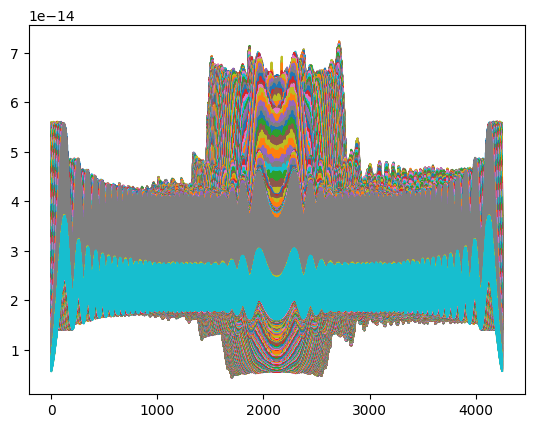

In [ ]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

In [16]:
from contextlib import redirect_stdout
with open('output_3d_test_DT_260608.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            for j in range(len(wf[0][i])):
                print(wf[0][i][j])
            print('\n')

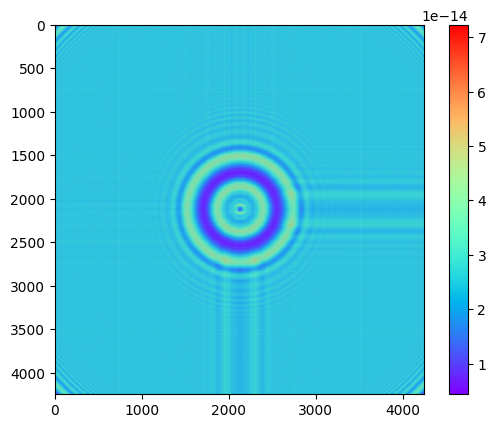

In [13]:
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()

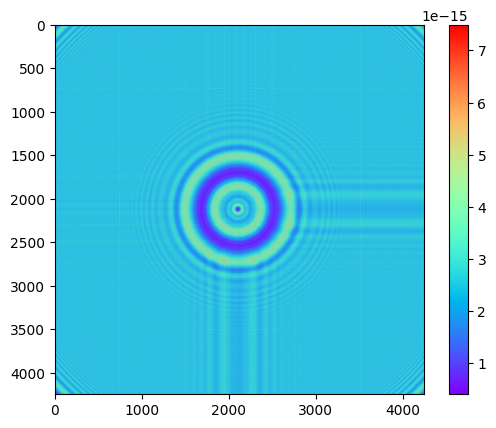

In [12]:
# one single shot
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()